In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [13]:
df = pd.read_excel('./height_weight.xlsx')
print(df.head())

   Weight_kg  Height_cm
0       66.3      174.0
1       67.8      168.9
2       71.2      175.2
3       72.9      182.2
4       68.4      168.1


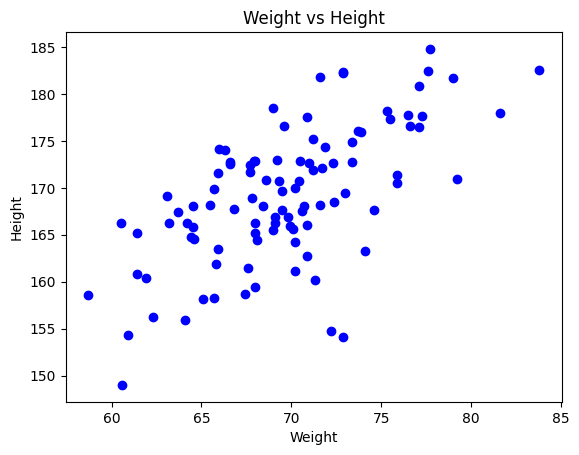

In [14]:
#scatter plot
plt.scatter(df['Weight_kg'], df['Height_cm'], color='blue')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

In [19]:
# correlation heatmap
df.corr()

,Weight_kg,Height_cm
Weight_kg,1.000000,0.635699
Height_cm,0.635699,1.000000


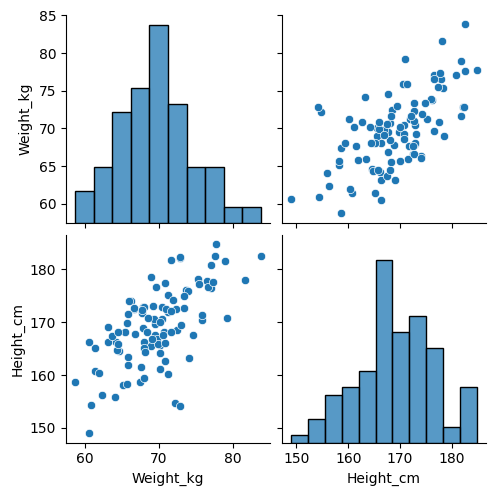

In [16]:
# seaborn for visualization
sns.pairplot(df)

<Axes: xlabel='Weight_kg', ylabel='Height_cm'>

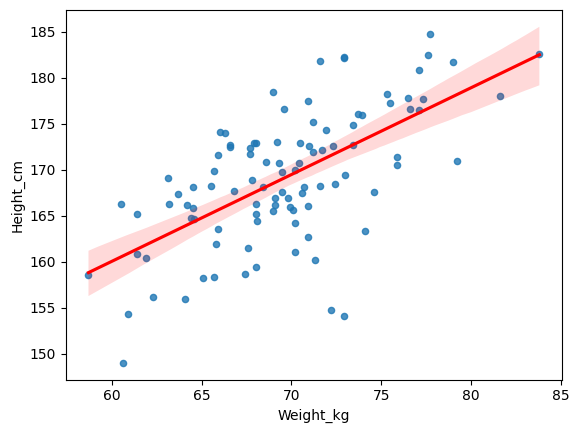

In [17]:
import seaborn as sns
sns.regplot(x='Weight_kg', y='Height_cm', data=df, scatter_kws={'s':20}, line_kws={'color':'red'})

In [18]:
from scipy.stats import pearsonr
corr, p = pearsonr(df['Height_cm'], df['Weight_kg'])
print(corr, p)

0.6356993689262019 1.198909569576017e-12


In [22]:
X = df[['Weight_kg']]
y = df['Height_cm']
type(X)
y.shape

(100,)

In [23]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [24]:
X_train.shape

(75, 1)

In [25]:
# standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
X_test

array([[-0.01398951],
       [ 0.70605862],
       [-0.42544558],
       [ 0.0477289 ],
       [-1.00148408],
       [-0.83690165],
       [ 1.22037871],
       [ 0.33574815],
       [-1.94783304],
       [-0.75461043],
       [ 0.19173853],
       [-1.76267781],
       [ 1.57011637],
       [-0.48716399],
       [-0.28143595],
       [-0.32258156],
       [ 0.08887451],
       [ 0.95293226],
       [ 0.25345694],
       [ 1.59068917],
       [ 0.19173853],
       [-1.1249209 ],
       [-1.76267781],
       [-1.41294015],
       [-1.1454937 ]])

In [28]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
regression.coef_

array([4.87820123])

In [30]:
regression.intercept_

np.float64(169.14666666666668)

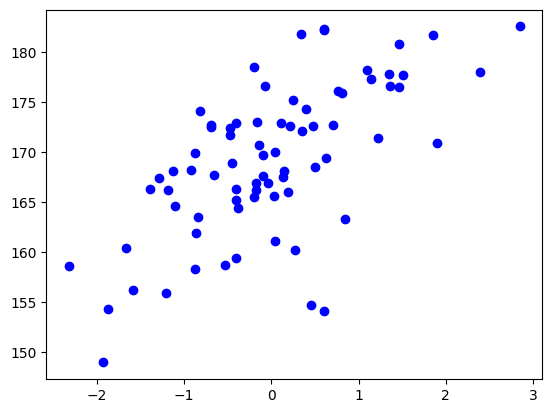

In [34]:
plt.scatter(X_train, y_train, color='blue')

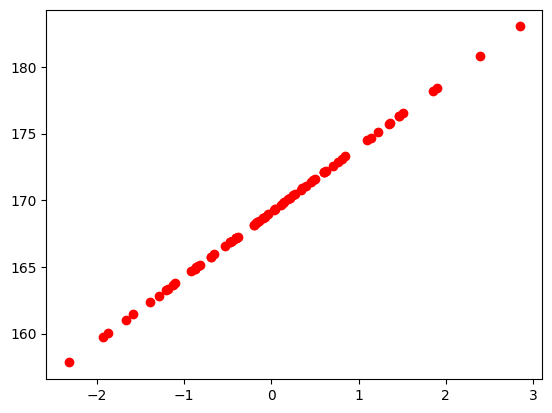

In [35]:
plt.scatter(X_train, regression.predict(X_train), color='red')

In [36]:
y_pred = regression.predict(X_test)

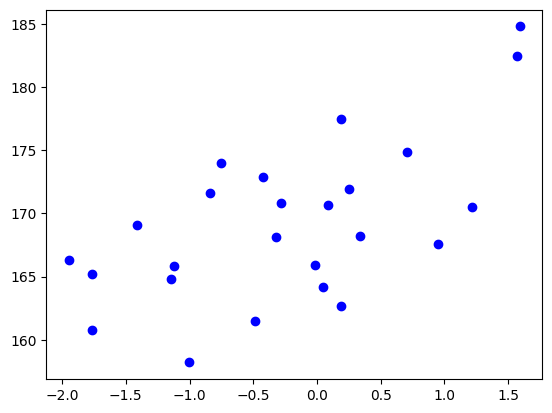

In [37]:
plt.scatter(X_test, y_test, color='blue')

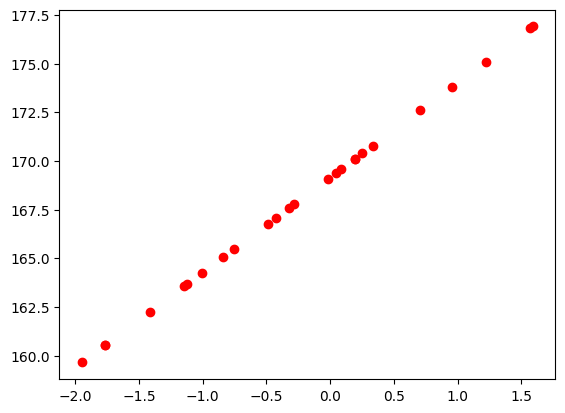

In [44]:
plt.scatter(X_test, regression.predict(X_test), color='red')

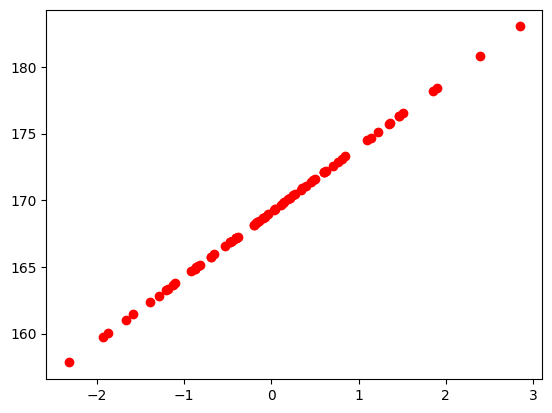

In [43]:
plt.scatter(X_train, regression.predict(X_train), color='red')

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)
print('Adjusted R2 Score:', adjusted_r2)


Mean Absolute Error: 4.505686420285913
Mean Squared Error: 26.35020865034806
Root Mean Squared Error: 5.133245430558338
R2 Score: 0.3187639955959658
Adjusted R2 Score: 0.2891450388827469


In [48]:
# OLS Regression Summary
%pip install statsmodels
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

Note: you may need to restart the kernel to use updated packages.


In [49]:
predictions = model.predict(X_test)
print("Predictions:", predictions)

Predictions: [-0.06824363  3.44429602 -2.07540914  0.2328312  -4.88544086 -4.08257466
  5.95325291  1.63784706 -9.50192154 -3.68114155  0.93533913 -8.59869706
  7.6593436  -2.37648397 -1.37290121 -1.57361776  0.43354775  4.64859533
  1.23641396  7.75970188  0.93533913 -5.48759051 -8.59869706 -6.89260637
 -5.58794879]


In [50]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              Height_cm   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):             -0.013
Method:                 Least Squares   F-statistic:                            0.06148
Date:                Thu, 08 Jan 2026   Prob (F-statistic):                       0.805
Time:                        23:33:28   Log-Likelihood:                         -491.27
No. Observations:                  75   AIC:                                      984.5
Df Residuals:                      74   BIC:                                      986.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [51]:
# Prediction on new data
new_data = np.array([[70], [80], [90]])
new_data_scaled = scaler.transform(new_data)
predictions_new = regression.predict(new_data_scaled)
print("Predicted Heights for new weights:", predictions_new)

Predicted Heights for new weights: [169.17878131 179.21460888 189.25043645]
